# <p align = "center"> Conformation Analysis </p>


In [1]:
from pathlib import Path
rootdir = Path("../../../..").resolve()
import sys
sys.path.insert(0, str(rootdir) )
from typing import Callable, Generator

import gemmi 
import parasail
import numpy as np
from rdkit import Chem

from xaidar.data.molecModels import get_pdb_stats, sele_pdb, sele_Lig, get_res_CoM
from xaidar.data.molecModels import flatten_pdb, sele_AA, createPDB, get_atom_coord

# Looking at natural flexibility of Ground-state Active Site



- # B-factors

In [2]:
# Load Fragalysis data (nonactivepdbs_dir, fragscreen_dir, piperid_dir, ...)

# 1. Loading Fragalyis data Root Directory
rootProjDir = rootdir / "data/ev2a/fragalysis"
fragalysisDir =  rootdir / "data/ev2a/fragalysis"

# 2. Load Fragalysis Protein Directories
nonactivepdbs_dir = fragalysisDir / "02-chemofint/nonactivesite"
fragscreen_dir = fragalysisDir / "02-chemofint/fragscreen"
piperid_dir = fragalysisDir / "02-chemofint/piperid"

# 3. Load Fragalysis Ligand Files
fragScreenLigPath = fragalysisDir / "02-chemofint/fragscreen_lig.sdf"
fragScreenLigs = Chem.SDMolSupplier( str(fragScreenLigPath), removeHs=False)
piperidLigPath = rootProjDir / "02-chemofint/piperidir_lig.sdf"
piperidLigs = Chem.SDMolSupplier( str(piperidLigPath), removeHs=False)


In [3]:
# Calculate mean CoM for all ligands (mean_CoM)
from xaidar.data.molecModels import rdkit_to_gemmi

lst_ligs = [ flatten_pdb( lig_pdb, "residue")[0] for lig_pdb in rdkit_to_gemmi(piperidLigs)]
CoM_array = get_res_CoM(  lst_ligs  )
# print( "Ligands CoM array shape: ", CoM_array.shape)
mean_CoM = CoM_array.mean(axis=0)
mean_CoM = gemmi.Position( *mean_CoM )
print( "Mean CoM from all ligands: ",mean_CoM )

Mean CoM from all ligands:  <gemmi.Position(8.93134, 13.2798, 23.3181)>


In [4]:
# Filter Protein Sequences to only chains closest to the ligands mean CoM -> (lst_prots, prot_logs)
from xaidar.data.protocols import load_and_filter_Proteins

nonactive_prots, nonactive_logs = load_and_filter_Proteins( nonactivepdbs_dir, 
                                                                    mean_CoM )
fragscreen_prots, fragscreen_logs = load_and_filter_Proteins( fragscreen_dir, 
                                                                    mean_CoM )
piperid_prots, piperid_logs = load_and_filter_Proteins( piperid_dir, 
                                                                    mean_CoM )

print("\t\t       #Dirs  #AfterFilter")
print( "Nonactive Proteins:\t{}\t{}".format(len(list(nonactivepdbs_dir.iterdir())),
                                             len(nonactive_prots)))
print("FragScreen Proteins:\t{}\t{}".format(len(list(fragscreen_dir.iterdir())),
                                            len(fragscreen_prots)))
print("Piperid Proteins:  \t{}\t{}".format(len(list(piperid_dir.iterdir())),
                                           len(piperid_prots)))


		       #Dirs  #AfterFilter
Nonactive Proteins:	99	99
FragScreen Proteins:	42	42
Piperid Proteins:  	454	454


# A.A. Chain Sanity Check 

In [5]:
# Check consistency of filtered proteins (lst_prots, prot_logs)
    # Expected Properties: Number of chains = 1, Number of models = 1, Chain size = 140
for lst_prots, prot_logs, name in zip([nonactive_prots, fragscreen_prots, piperid_prots]
                                      ,[nonactive_logs, fragscreen_logs, piperid_logs],
                                        ["Nonactive", "FragScreen", "Piperid"]):
    print("\nChecking consistency of {} filtered proteins".format(name))
    lst_sizes, lst_seqs, lst_chains, lst_models = [ list(set( prot_logs["chainSize"])), 
    list(set( prot_logs["sequence"])), list(set(prot_logs["NumChains"])), list(set( prot_logs["NumModels"])) ]

    if len(lst_sizes) > 1 or len(lst_seqs) > 1 or len(lst_chains) > 1 or len(lst_models) > 1:
        print("Warning: Inconsistent number of chains or models in the selected proteins")
        print("Chain sizes: ", lst_sizes)
        print("Number of models: ", lst_models)
        # print( "Sequences: ", lst_seqs)
    elif lst_sizes[0] != 140 or lst_chains[0] != 1 or lst_models[0] != 1:
        print("Warning: Unexpected number of chains or models in the selected proteins")
        print("Chain sizes: ", lst_sizes)
        print("Number of chains: ", lst_chains)
        print("Number of models: ", lst_models)
    else:
        print("All selected proteins have consistent number of chains and models")
        print("Chain sizes: ", lst_sizes[0])
        print("Number of chains: ", lst_chains[0])
        print("Number of models: ", lst_models[0])

    count_dict = dict( zip(lst_sizes, [0]*len(lst_sizes) ) )
    for size in prot_logs["chainSize"]: count_dict[size] += 1

    title = "Size: "
    for size in lst_sizes: title += " {}\t|".format(size)

    count = "Count: "
    for size in lst_sizes: count += " {}\t|".format(count_dict[size])
    
    index = "Eg Idx:"
    for size in lst_sizes: index += " {}\t|".format(prot_logs["chainSize"].index(size))
    print( title)
    print( count)
    print( index)


    # prot138, prot139, prot140, prot141 = [ lst_prots[44], lst_prots[3], lst_prots[00],
    #                                     lst_prots[30] ]


Checking consistency of Nonactive filtered proteins
Chain sizes:  [138, 139, 140, 141]
Number of models:  [1]
Size:  138	| 139	| 140	| 141	|
Count:  2	| 20	| 74	| 3	|
Eg Idx: 44	| 3	| 0	| 30	|

Checking consistency of FragScreen filtered proteins
Chain sizes:  [138, 139, 140]
Number of models:  [1]
Size:  138	| 139	| 140	|
Count:  3	| 11	| 28	|
Eg Idx: 13	| 1	| 0	|

Checking consistency of Piperid filtered proteins
Chain sizes:  [138, 139, 140]
Number of models:  [1]
Size:  138	| 139	| 140	|
Count:  14	| 364	| 76	|
Eg Idx: 58	| 0	| 8	|


- ### Perform Sequence Alignment

In [6]:
# Align all sequences and check for mismatches
from xaidar.data.molecModels import model_seqAlign
lst_prots = nonactive_prots
num_chains = len(lst_prots)
mismatch_lst = []
for i in range(num_chains):
    for j in range(i+1, num_chains):
        alignment_result = model_seqAlign( lst_prots[i], lst_prots[j]).check_match(verbose=False).match_status
        if not alignment_result: mismatch_lst.append( (i,j) )

print("Number of mismatches found:{} / {} ".format(len(mismatch_lst),num_chains*(num_chains-1)//2 ))

Number of mismatches found:2132 / 4851 


In [7]:
# Looking into specific mismatches
from xaidar.data.molecModels import model_seqAlign
nonactive_idx, fragscreen_idx, piperid_idx = [44 , 3, 0	,30], [13, 1, 0] , [58, 0, 8]
idx1, idx2 = nonactive_idx[:2]

lst_prots = nonactive_prots
alignment = model_seqAlign( lst_prots[30], lst_prots[0]).align().visualize().check_match()


                |         |         |         |         *         |         |         |         |         +         |         |         |         | 
Ref:   SGAIYVGNYRVVNRHLATHNDWANLVWEDSSRDLLVSSTTAQGCDTIARCNCQTGVYYCSSKRKHYPVSFTKPSLIFVEASEYYPARYQSHLMLAVGHSEPGDCGGILRCQHGVVGIVSTGGNGLVGFADVRDLLWLDDEA
       ||||||||||||||||||||||||||||||||||||||||||||||||||:||||||||||:||||||||:|||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||:| 
Query: SGAIYVGNYRVVNRHLATHNDWANLVWEDSSRDLLVSSTTAQGCDTIARCDCQTGVYYCSSRRKHYPVSFSKPSLIFVEASEYYPARYQSHLMLAVGHSEPGDCGGILRCQHGVVGIVSTGGNGLVGFADVRDLLWLDEE-
Mismatch in residue serial numbers between reference and query.


- ### Checking Amino Acid Distribution Variation across Different Chains

In [8]:
# Pick Largest Chain as Reference Chain
from xaidar.data.molecModels import get_chain_seq
ref_seq = get_chain_seq( flatten_pdb(nonactive_prots[30], "chain") )[0]
print("Reference Sequence (Non Active Prot idx 30):\n ", ref_seq)
print( "Chain Size: ", len(ref_seq) )
print( "Last Amino acid: ", ref_seq[140] )

Reference Sequence (Non Active Prot idx 30):
  SGAIYVGNYRVVNRHLATHNDWANLVWEDSSRDLLVSSTTAQGCDTIARCNCQTGVYYCSSKRKHYPVSFTKPSLIFVEASEYYPARYQSHLMLAVGHSEPGDCGGILRCQHGVVGIVSTGGNGLVGFADVRDLLWLDDEA
Chain Size:  141
Last Amino acid:  A


In [9]:
# Get aa sequences for all proteins aligned to reference chain -> all_query_seqs: [ [nonactive], [fragscreen], [piperid] ]
all_query_seqs = []
lst_prots = nonactive_prots
for lst_prots in [nonactive_prots, fragscreen_prots, piperid_prots]:
    num_chains = len(lst_prots)
    query_seqs = []
    for i in range(num_chains):
        # if i != 30 and name != "nonactive": # includes reference into query seqs
        alignment = model_seqAlign( nonactive_prots[30], lst_prots[i]).check_match(verbose=False)
        alignment_result = alignment.match_status
        ref_seq = alignment.result.traceback.ref
        ref_seq_gaps = [ idx for idx, char in enumerate(ref_seq) if char == '-']
        query_seq = alignment.result.traceback.query
        query_seq = [ char for idx, char in enumerate(query_seq) if idx not in ref_seq_gaps ]
        query_seq_str = "".join( query_seq )
        query_seqs.append( query_seq_str )
    all_query_seqs.append( query_seqs )           

In [10]:
# Look at positions with multiple AAs across sequences
for query_seqs, name in zip( all_query_seqs,                                    # Compare variability in each dataset
                            ["Nonactive", "FragScreen", "Piperid"] ):
    print("\nAnalyzing sequence variability in {} dataset".format(name))
    order_seq_lst = list( zip( *query_seqs)  )
    order_seq_sets = [ set( seqs) for seqs in order_seq_lst ]
    multiple_aa_pos = [ (idx, aa_set) for idx, aa_set in enumerate(order_seq_sets) if len(aa_set) > 1 ]
    # print("\t", order_seq_sets[:5] )
    print("\tPositions with multiple AAs across sequences:")
    for pos, aa_set in multiple_aa_pos:
        print("\tPosition {}: AAs {}".format(pos + 1, aa_set) )

flat_all_query_seqs = [ seq for sublist in all_query_seqs for seq in sublist ]  # Look at all sequences together
print("\nAnalyzing sequence variability in all dataset")
order_seq_lst = list( zip( *flat_all_query_seqs)  )
order_seq_sets = [ set( seqs) for seqs in order_seq_lst ]
multiple_aa_pos = [ (idx, aa_set) for idx, aa_set in enumerate(order_seq_sets) if len(aa_set) > 1 ]
# print("\t", order_seq_sets[:5] )
print("\tPositions with multiple AAs across sequences:")
for pos, aa_set in multiple_aa_pos:
    print("\tPosition {}: AAs {}".format(pos + 1, aa_set) )


# test = [dict()]*141
# test[0]["hi"] = 1
# # test[0]["hi"] = 1
# # print( test["hi"])


Analyzing sequence variability in Nonactive dataset
	Positions with multiple AAs across sequences:
	Position 51: AAs {'D', 'N'}
	Position 62: AAs {'K', 'R'}
	Position 71: AAs {'T', 'S'}
	Position 139: AAs {'E', 'D', '-'}
	Position 140: AAs {'E', '-'}
	Position 141: AAs {'A', '-'}

Analyzing sequence variability in FragScreen dataset
	Positions with multiple AAs across sequences:
	Position 139: AAs {'E', '-'}
	Position 140: AAs {'E', '-'}

Analyzing sequence variability in Piperid dataset
	Positions with multiple AAs across sequences:
	Position 139: AAs {'E', '-'}
	Position 140: AAs {'E', '-'}

Analyzing sequence variability in all dataset
	Positions with multiple AAs across sequences:
	Position 51: AAs {'D', 'N'}
	Position 62: AAs {'K', 'R'}
	Position 71: AAs {'T', 'S'}
	Position 139: AAs {'E', 'D', '-'}
	Position 140: AAs {'E', '-'}
	Position 141: AAs {'A', '-'}


In [11]:
# Count AA occurrences at positions of aa substitution (50, 61, 70)
count_dict= {pos : 
                { aa : order_seq_lst[pos].count(aa)  
                        for aa in order_seq_sets[pos] }
                                    for pos in [50, 61, 70]}


In [12]:
# Create a summary table of AA distribution at selected positions (e.g., 50, 61, 70)
import pandas as pd
summary_data = []

for pos in [50, 61, 70]:
    aa_counts = count_dict[pos]
    total_counts = sum(aa_counts.values())
    for aa, count in aa_counts.items():
        frequency = count / total_counts
        summary_data.append({
            "Position": pos + 1,  # Convert to 1-based index
            "Amino Acid": aa,
            "Count": count,
            "Frequency": frequency
        })  
summary_df = pd.DataFrame(summary_data)
summary_df.sort_values(by=["Position",  "Count",], inplace=True)
print("\nAmino Acid Distribution Summary at\n\tSelected Positions:")
display(summary_df)


Amino Acid Distribution Summary at
	Selected Positions:


,Position,Amino Acid,Count,Frequency
1,51,N,10,0.016807
0,51,D,585,0.983193
2,62,K,10,0.016807
3,62,R,585,0.983193
4,71,T,10,0.016807
5,71,S,585,0.983193


# Find Good the Reference Model

- It will against it that the a.a.s will be analysed

In [13]:
# See if the large chains (size 141) have the expected sequence 
large_Chains_idx = [ id for id, size in enumerate( nonactive_logs["chainSize"])
                                                                 if size == 141]
def commonseq(seq):
    match_dict = {50:"D", 61:"R", 70:"S"}
    failed_idx = []
    for pos, aa in match_dict.items():
        if seq[pos] != aa: 
            failed_idx.append( pos)    
    return failed_idx

print("\nChecking large chains (size 141) in Nonactive dataset:")
for idx in large_Chains_idx:
    seq = get_chain_seq( flatten_pdb(nonactive_prots[idx], "chain") )[0]
    unmatched_pos = commonseq( seq)
    if  unmatched_pos == []:
        print("\tFound matching sequence at Prot idx: ", idx)
    else:
        print("\tProt idx: {} - failed at positions: {}".format(idx, unmatched_pos))


if  commonseq( get_chain_seq(fragscreen_prots[0] )[0] ) == []:
    print("\nFound matching sequence:   **FragScreen Prot with idx 0**\n")

    model_seqAlign(  fragscreen_prots[0], nonactive_prots[30],).visualize()


Checking large chains (size 141) in Nonactive dataset:
	Prot idx: 30 - failed at positions: [50, 61, 70]
	Prot idx: 61 - failed at positions: [50, 61, 70]
	Prot idx: 64 - failed at positions: [50, 61, 70]

Found matching sequence:   **FragScreen Prot with idx 0**

                |         |         |         |         *         |         |         |         |         +         |         |         |         | 
Ref:   SGAIYVGNYRVVNRHLATHNDWANLVWEDSSRDLLVSSTTAQGCDTIARCDCQTGVYYCSSRRKHYPVSFSKPSLIFVEASEYYPARYQSHLMLAVGHSEPGDCGGILRCQHGVVGIVSTGGNGLVGFADVRDLLWLDEE-
       ||||||||||||||||||||||||||||||||||||||||||||||||||:||||||||||:||||||||:|||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||:| 
Query: SGAIYVGNYRVVNRHLATHNDWANLVWEDSSRDLLVSSTTAQGCDTIARCNCQTGVYYCSSKRKHYPVSFTKPSLIFVEASEYYPARYQSHLMLAVGHSEPGDCGGILRCQHGVVGIVSTGGNGLVGFADVRDLLWLDDEA


In [14]:
# Get stats for reference protein
ref_prot = fragscreen_prots[0].clone()
ref_seq = get_chain_seq( ref_prot)[0]
print( "Length of Ref Seq: ", len(ref_seq))
get_pdb_stats( ref_prot )

Length of Ref Seq:  140

####################
Number of models: 1
Number of chains in 1st Model: 1

Chain ID: A
	Number of Residues: 140
	Unique List of Non-A.A.: set()
	Contains A.A.


# Get Query AAs against Ref AAs 

In [15]:
from xaidar.data.molecModels import model_seqAlign, get_aa_distribution
nonactive_aa_distrib_dict = get_aa_distribution( ref_prot, nonactive_prots, )
fragscreen_aa_distrib_dict = get_aa_distribution( ref_prot, fragscreen_prots, )
piperid_aa_distrib_dict = get_aa_distribution( ref_prot, piperid_prots,)
# print([res.name for res in aa_distrib_dict[0]])

### Extract Average b-factor value per amino acid

In [49]:
# Calculate b-factors for all residue sequences in nonactive_aa_distrib_dict
from xaidar.data.molecModels import get_res_bfactors

aa_distrib_lst = [ nonactive_aa_distrib_dict, fragscreen_aa_distrib_dict,
                   piperid_aa_distrib_dict ]
prot_names = ["Nonactive", "FragScreen", "Piperid" ]
aa_distrib_dict = {}
for aa_distrib, name in zip( aa_distrib_lst , prot_names):
    print("Calculating b-factors for {} dataset".format(name))

    res_seqs = list( zip( *aa_distrib.values()) ) # nonactive_aa_distrib_dict
    all_seqs_bfactors = []
    for res_seq in res_seqs: all_seqs_bfactors.append( get_res_bfactors( res_seq, sign_fig = 5) )
    all_seqs_bfactors = [ [ value if value != None else np.nan for value in seq_bfactors ]
                                            for seq_bfactors in all_seqs_bfactors ]
    aa_distrib_dict[name] = all_seqs_bfactors

print()
for name in prot_names:
    print( f"{name} number of residue sequences: ", len(aa_distrib_dict[name]))

print( "\nNumber of residue sequences: ", len(aa_distrib_dict["Nonactive"]))
print( "Number of residues per sequence: ", len(aa_distrib_dict["Nonactive"][0]) )
print( "First 10 residue b-factors: ", aa_distrib_dict["Nonactive"][0][:10])

Calculating b-factors for Nonactive dataset
Calculating b-factors for FragScreen dataset
Calculating b-factors for Piperid dataset

Nonactive number of residue sequences:  99
FragScreen number of residue sequences:  42
Piperid number of residue sequences:  454

Number of residue sequences:  99
Number of residues per sequence:  140
First 10 residue b-factors:  [16.435, 14.0975, 13.116, 12.4375, 16.83083, 16.96429, 18.4375, 23.0575, 19.07, 14.48818]


In [ ]:
# Calcluate mean and std dev of b-factors at each residue position across all sequences
all_bfactor_dict = {}

for dataset_name in aa_distrib_dict.keys():
    bfactor_dict = {}
    bfactor_dict["values"] = np.array( aa_distrib_dict[dataset_name] )
    bfactor_dict["mean"] = np.nanmean( bfactor_dict["values"], axis=0)
    bfactor_dict["std"] = np.nanstd( bfactor_dict["values"], axis=0)
    all_bfactor_dict[ dataset_name ] = bfactor_dict

# bfactor_values = np.array( all_seqs_bfactors )
# bfactor_mean = np.nanmean(bfactor_values, axis=0)
# bfactor_std = np.nanstd(bfactor_values, axis=0)
for name in prot_names:
    print( f"{name} Bfactor values array shape: ", all_bfactor_dict[name]["values"].shape )
print()
for name in prot_names:
    print( f"{name} Bfactor means array shape: ", all_bfactor_dict[name]["mean"].shape )
print()
for name in prot_names:
    print( f"{name} Bfactor std array shape: ", all_bfactor_dict[name]["std"].shape )


Nonactive Bfactor values array shape:  (99, 140)
FragScreen Bfactor values array shape:  (42, 140)
Piperid Bfactor values array shape:  (454, 140)

Nonactive Bfactor means array shape:  (140,)
FragScreen Bfactor means array shape:  (140,)
Piperid Bfactor means array shape:  (140,)

Nonactive Bfactor std array shape:  (140,)
FragScreen Bfactor std array shape:  (140,)
Piperid Bfactor std array shape:  (140,)


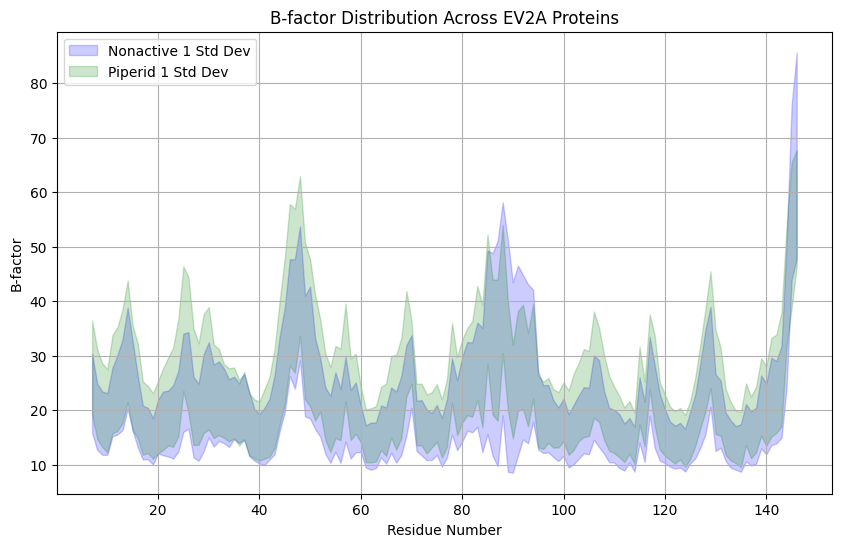

In [59]:
# Plot b-factors Distribution
import matplotlib.pyplot as plt
residues_num = np.arange(7, len(ref_seq)+7)
plt.figure(figsize=(10,6))
for dataset_name, color in zip(["Nonactive", "Piperid","FragScreen",  ][:-1], ['blue', 'green', 'red'][:-1]):
    bfactor_mean = all_bfactor_dict[ dataset_name ]["mean"]
    bfactor_std = all_bfactor_dict[ dataset_name ]["std"]
    # plt.plot( residues_num, bfactor_mean, label="{} Mean".format(dataset_name)
    #          , color= color)
    plt.fill_between( residues_num, bfactor_mean - bfactor_std,
                      bfactor_mean + bfactor_std, color=color, alpha=0.2,
                    label="{} 1 Std Dev".format(dataset_name) )
plt.xlabel("Residue Number")
plt.ylabel("B-factor")
plt.title("B-factor Distribution Across EV2A Proteins")
plt.legend()
plt.grid()
plt.show()

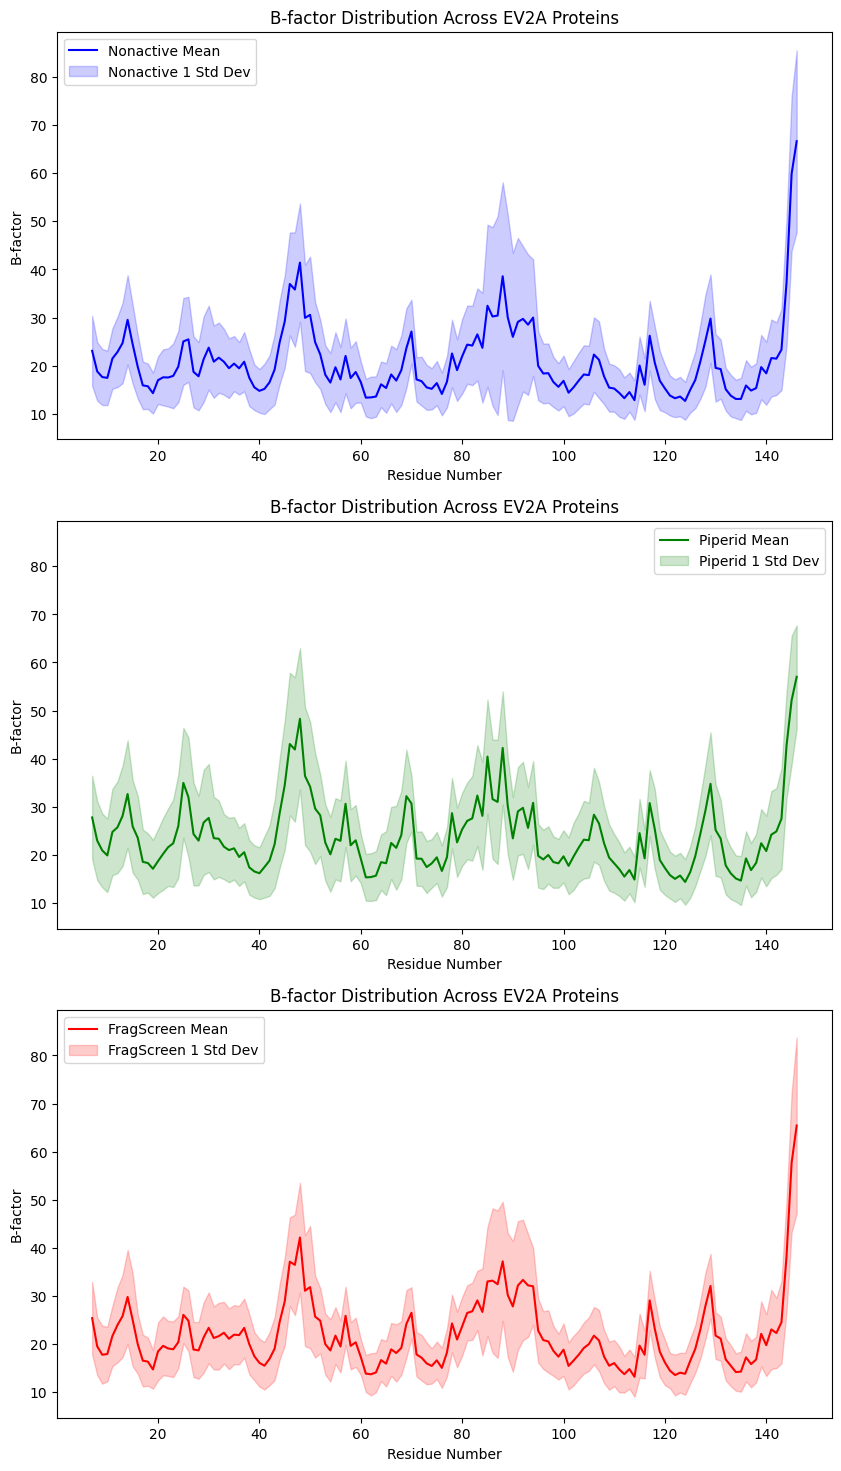

In [54]:
# Plot b-factors Distribution
import matplotlib.pyplot as plt
residues_num = np.arange(7, len(ref_seq)+7)
fig, ax  = plt.subplots( 3, 1 ,  figsize=(10,18), sharey=True)
for idx, (dataset_name, color) in enumerate(zip(["Nonactive", "Piperid","FragScreen",  ], ['blue', 'green', 'red'])):
    bfactor_mean = all_bfactor_dict[ dataset_name ]["mean"]
    bfactor_std = all_bfactor_dict[ dataset_name ]["std"]
    ax[idx].plot( residues_num, bfactor_mean, label="{} Mean".format(dataset_name)
             , color= color)
    ax[idx].fill_between( residues_num, bfactor_mean - bfactor_std,
                      bfactor_mean + bfactor_std, color=color, alpha=0.2,
                    label="{} 1 Std Dev".format(dataset_name) )
    ax[idx].set_xlabel("Residue Number")
    ax[idx].set_ylabel("B-factor")
    ax[idx].set_title("B-factor Distribution Across EV2A Proteins")
    ax[idx].legend()
# plt.grid()
plt.show()